# Filtro anti-hater per social network: Moderazione Avanzata dei Contenuti con Deep Learning
Negli ultimi anni, la moderazione dei contenuti online è diventata una sfida cruciale per molte piattaforme, che si trovano ad affrontare un volume crescente di commenti potenzialmente dannosi. Questi commenti possono includere insulti, minacce, contenuti osceni o messaggi di odio. La moderazione manuale è inefficace su larga scala, e gli algoritmi tradizionali spesso non riescono a catturare la complessità e la varietà dei linguaggi offensivi.

## DeepCortex AI Solutions
**DeepCortex AI Solutions** ha deciso di sviluppare un sistema avanzato basato su tecnologie di Deep Learning per automatizzare e migliorare il processo di moderazione. Il cuore del progetto è un modello di deep learning con **layer ricorrenti**, progettato per classificare commenti in più categorie di tossicità.

## Il Problema da RisolvereL'azienda
**TechTalk**, un forum per appassionati di tecnologia, ha riscontrato che un numero significativo di commenti pubblicati nei thread della community contiene espressioni di odio e insulti che compromettono la qualità delle discussioni. Gli utenti hanno segnalato che la piattaforma, a causa della sua popolarità crescente, fatica a gestire il flusso di commenti dannosi con strumenti di moderazione tradizionali. **TechTalk** si è rivolta a **DeepCortex AI Solutions** per implementare una soluzione di moderazione automatica basata su Deep Learning, che sia in grado di filtrare in tempo reale i commenti tossici.

### Caso d'Uso
Scenario reale: Mario Rossi, community manager di **TechTalk**, si occupa quotidianamente della moderazione manuale dei contenuti generati dagli utenti. Con l’aumento del traffico sulla piattaforma, Mario non riesce più a gestire manualmente la quantità di commenti dannosi, e deve trovare un modo per filtrare automaticamente i commenti offensivi, minacciosi o osceni senza rallentare l'esperienza utente.

## Requisiti Tecnici del Modello

### TaskClassificazione multi-label dei commenti in 6 categorie:

* **Toxic** (Tossico)
* **Severely Toxic** (Super Tossico)
* **Obscene** (Osceno)
* **Threat** (Minaccia)
* **Insult** (Insulto)
* **Identity Hate** (Odio basato sull’identità)

### Dataset
Un dataset di 160.000 commenti sarà fornito, con ogni commento etichettato in una o più delle categorie sopra indicate. I commenti possono avere zero o più label attive.

### Architettura
Il modello deve includere **layer ricorrenti** (ad esempio, LSTM o GRU) per gestire la natura sequenziale dei commenti testuali.

### Output
A livello di inferenza, per ogni commento, il modello dovrà produrre un vettore di 6 elementi (uno per ogni label), con valori binari (0 o 1), dove 1 indica la presenza della label corrispondente e 0 la sua assenza.

## Fasi del Progetto
### Preprocessing dei Dati
* I commenti testuali devono essere convertiti in sequenze numeriche (tokenizzazione).
* I dati devono essere normalizzati e bilanciati per garantire che tutte le categorie di tossicità siano rappresentate equamente.

### Sviluppo del Modello
* Il modello di deep learning sarà basato su un'architettura ricorrente, in grado di catturare le dipendenze a lungo termine tra le parole nei commenti.
* Verranno implementati strati ricorrenti (LSTM o GRU) per il task di classificazione multi-label.

### Training del Modello
* Il dataset sarà suddiviso in training, validation e test set.
* Utilizzo di tecniche di ottimizzazione avanzata per migliorare la convergenza del modello.

### Inferenza e Predizione
* Durante il tempo di inferenza, per ogni commento, il modello restituirà un vettore di 6 elementi con 0 o 1, a seconda della presenza di tossicità in una o più delle categorie previste.

### Validazione
* Il modello sarà valutato utilizzando metriche come *accuracy*, *F1-score* per ciascuna categoria, e *precisione* globale nella previsione delle label multiple.

## Valore Aggiunto
* **Automazione:** Il modello ridurrà significativamente il carico di lavoro della moderazione manuale, permettendo a **TechTalk** di gestire un numero maggiore di commenti in tempo reale, mantenendo un ambiente sicuro per gli utenti.
* **Efficienza:** Grazie all'uso di layer ricorrenti, il modello sarà in grado di catturare meglio il contesto e le sfumature dei commenti testuali, migliorando l'accuratezza delle previsioni rispetto a metodi tradizionali.
* **Scalabilità:** Una volta implementato, il sistema sarà facilmente scalabile per gestire volumi crescenti di dati, adattandosi al crescente numero di utenti e commenti sulla piattaforma.
* **Integrazione:** La soluzione sarà integrata direttamente nel sistema di commenti di **TechTalk**, rendendo il filtraggio automatico immediatamente operativo e senza impattare negativamente l'esperienza degli utenti.

## Dataset
Il dataset è scaricabile da questo link: `https://proai-datasets.s3.eu-west-3.amazonaws.com/Filter_Toxic_Comments_dataset.csv`

## Conclusione
Il progetto di **DeepCortex AI Solutions** fornirà una soluzione avanzata e automatizzata per la moderazione dei contenuti tossici, migliorando significativamente la qualità delle discussioni online su **TechTalk**. Il sistema garantirà una gestione più efficiente e accurata dei commenti, offrendo una piattaforma sicura e inclusiva per tutti gli utenti.


# Librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.backend import clear_session
from tensorflow.keras.layers import Dense, LSTM, Embedding, Input, Bidirectional
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.metrics import BinaryAccuracy, Recall, Precision
from tensorflow.keras.models import load_model


from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from tensorflow.python.keras.models import load_model


# Funzioni utili

In [2]:
def max_len_sequences(sequences):
    max_len = 0
    for sequence in sequences:
        if len(sequence) > max_len:
            max_len = len(sequence)
        else:
            continue

    return max_len


In [3]:
def toxicity_weights_compute(label_occurrence, bad_comments):
    toxicity_weights = []
    for i in range(len(label_occurrence)):
        toxicity_weights.append(round((bad_comments/label_occurrence.iloc[i])**0.5,0))

    return tf.constant(toxicity_weights, dtype=tf.float32)


In [4]:
def weight_bce(y_true, y_pred):
    # 1. Assicuriamoci che siano float32 per evitare errori di tipo
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # 2. Formula manuale della Binary Cross Entropy
    # Aggiungiamo 1e-7 (un numero piccolissimo) per evitare il log(0) che crea i NaN
    epsilon = 1e-7
    bce = - (y_true * tf.math.log(y_pred + epsilon) + (1 - y_true) * tf.math.log(1 - y_pred + epsilon))

    # 3. Ora bce è sicuramente una matrice [32, 6]
    # Possiamo moltiplicarla per i nostri 6 pesi senza errori di shape
    weighted_bce = bce * toxicity_weights

    # 4. Infine facciamo la media di tutto per restituire lo scalare a Keras
    return tf.reduce_mean(weighted_bce)


In [5]:
def metrics_by_threshold(y_true, y_pred, thresholds):
    dict_metrics = {0:[], 1:[], 2:[], 3:[], 4:[], 5:[]}

    for column in dict_metrics.keys():
        accuracy = []
        precision = []
        recall = []
        f1 = []

        for threshold in thresholds:
            y_test_pred_bool = np.where(y_pred[:,column]>threshold,1,0)
            accuracy.append(accuracy_score(y_true[:,column], y_test_pred_bool))
            precision.append(precision_score(y_true[:,column], y_test_pred_bool,zero_division=0))
            recall.append(recall_score(y_true[:,column], y_test_pred_bool))
            f1.append(f1_score(y_true[:,column], y_test_pred_bool))

        column_metrics = [accuracy, precision, recall, f1]
        dict_metrics[column] = column_metrics

    return dict_metrics


In [6]:
def thresh_eval(dictionary, thresholds):
    plt.figure(figsize = (15,10))
    for column in dictionary.keys():
        plt.subplot(2,3,column+1)
        plt.plot(thresholds, np.array(dictionary[column]).T)
        plt.title(f'Metrics by Threshold for label: {df.columns[column+1]}')
        plt.legend(['Accuracy', 'Precision', 'Recall', 'F1'])
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.tight_layout()


In [7]:
def metrics_eval(y_true, y_pred, thresholds_final):
    for label in range(y_true.shape[1]):
        y_pred_bool = np.where(y_pred[:,label] > thresholds_final[label],1,0)

        accuracy = accuracy_score(y_true[:,label], y_pred_bool)
        precision = precision_score(y_test[:,label], y_pred_bool)
        recall = recall_score(y_test[:,label], y_pred_bool)
        f1 = f1_score(y_test[:,label], y_pred_bool)

        print(f'LABEL: {df.columns[label+1]}, TOXICITY WEIGHT: {toxicity_weights[label]}\n')
        print(confusion_matrix(y_test[:,label], y_pred_bool))
        print(f'Accuracy for label {df.columns[label+1]}: {100*accuracy:.2f}')
        print(f'Precision for label {df.columns[label+1]}: {100*precision:.2f}')
        print(f'Recall for label {df.columns[label+1]}: {100*recall:.2f}')
        print(f'F1 for label {df.columns[label+1]}: {100*f1:.2f}\n')
        print('---\n')

In [8]:
def global_metrics_eval(y_true, y_pred, thresholds_final):
    y_pred_bool = np.where(y_pred > thresholds_final,1,0)

    accuracy = accuracy_score(y_true, y_pred_bool)
    precision = precision_score(y_test, y_pred_bool,average='weighted')
    recall = recall_score(y_test, y_pred_bool, average='weighted')
    f1 = f1_score(y_test, y_pred_bool, average='weighted')

    print(f'Global accuracy of the model: {100*accuracy:.2f}')
    print(f'Global Precision of the model: {100*precision:.2f}')
    print(f'Global Recall of the model: {100*recall:.2f}')
    print(f'Global F1 of the model: {100*f1:.2f}\n')
    print('---\n')

In [9]:
def train_eval(dict1, dict2):
    plt.figure(figsize = (15,10))
    dict1_keys = list(dict1.keys())
    dict2_keys = list(dict2.keys())
    subplot = 1


    for i in range(int(len(history_1lstm.keys())/2)):
        plt.subplot(4,2,subplot)
        plt.plot(dict1[dict1_keys[i]])
        plt.plot(dict1[dict1_keys[i+4]])
        plt.title(f'Model 1_LSTM {dict1_keys[i]}')
        plt.legend(['Train', 'Validation'])
        plt.tight_layout()
        subplot += 1

        plt.subplot(4,2,subplot)
        plt.plot(dict2[dict2_keys[i]])
        plt.plot(dict2[dict2_keys[i+4]])
        plt.title(f'Model 2_LSTM {dict1_keys[i]}')
        plt.legend(['Train', 'Validation'])
        plt.tight_layout()
        subplot += 1

# Studio del dataset

In [10]:
DS_URL = 'https://proai-datasets.s3.eu-west-3.amazonaws.com/Filter_Toxic_Comments_dataset.csv'

In [11]:
df = pd.read_csv(DS_URL)

In [12]:
df.shape

(159571, 8)

In [13]:
df['comment_text'].unique().shape

(159571,)

In [14]:
df.head(15)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0
5,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0,0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0,4
7,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0,0
8,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0,0
9,alignment on this subject and which are contra...,0,0,0,0,0,0,0


## Bilanciamento commenti buoni vs cattivi

Verifichiamo ora, grazie all'utile colonna sum_injurious, se ci sia sblinaciamento tra commenti buoni e cattivi, aspettandoci ovviamente che ci siano molto più buoni che non.

In [15]:
labels_count = df['sum_injurious'].value_counts().sort_index()
labels_count

sum_injurious
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

Come era facilmente intuibile, i commenti che non avevano nessuna etichetta popolata sono enormemente più numerosi di quelli con almeno un'etichetta valorizzata.

Questa tematica dovrà chiaramente essere affrontata in sede di preprocessing per bilanciare il dataset.

Come ausilio per visualizzare lo sbilanciamento del dataset, si mette in grafico il numero di commenti per ogni valore di sum_injurious

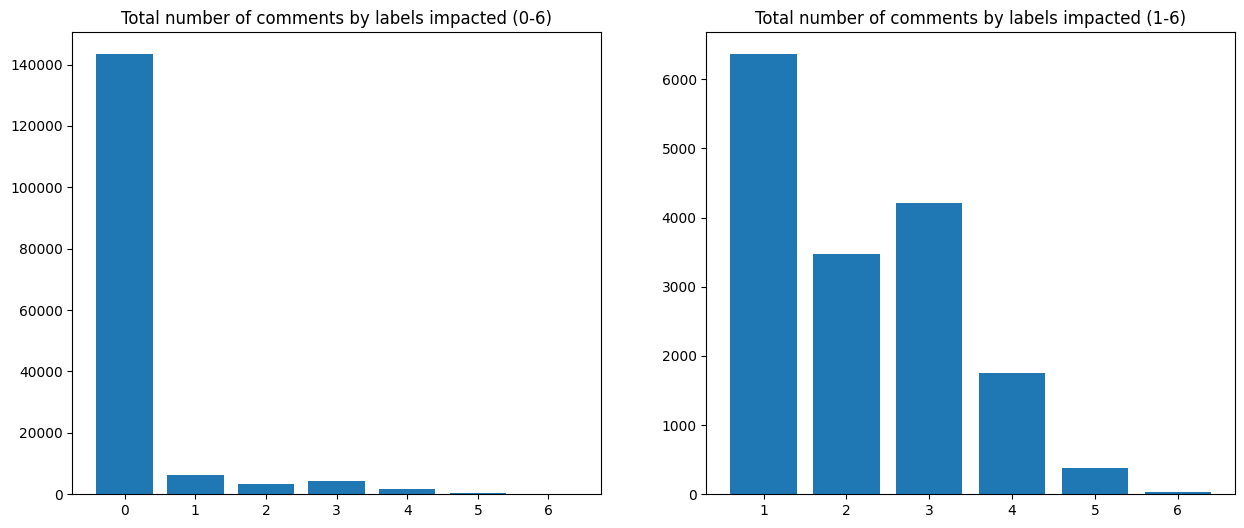

In [16]:
plt.figure(figsize = (15,6))

plt.subplot(1,2,1)
plt.bar(labels_count.index, labels_count)
plt.title('Total number of comments by labels impacted (0-6)')

plt.subplot(1,2,2)
plt.bar(labels_count.index[1:], labels_count[1:])
plt.title('Total number of comments by labels impacted (1-6)')

plt.show()

Dal grafico si percepisce, ancora piuù evidentemente, lo sbilanciamento tra i buoni e i cattivi. È stato inserito lo stesso grafico senza i buoni, per avere una migliore visione sul bilanciamento nella classe dei cattivi.

Anche in questo caso, come intuibile, le frequenze vanno a decrescere verso i commenti che abbiano tutte le etichette attive.

Anche questa cosa dovraà essere gestita prima dell'addestramento.

In [17]:
print(round(labels_count/labels_count.sum(),4)*100, labels_count)

sum_injurious
0    89.83
1     3.99
2     2.18
3     2.64
4     1.10
5     0.24
6     0.02
Name: count, dtype: float64 sum_injurious
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64


In [18]:
bad_comments = labels_count[1:].sum()
good_comments = labels_count[0]
print(good_comments, bad_comments)

143346 16225


In [19]:
label_occurrence = df.loc[:, 'toxic':'identity_hate'].sum()
label_occurrence

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

## Conclusioni
Il dataset risulta, come usuale in questo genere di problemi, un forte sbilanciamento su commenti non ingiuriosi.

Altro punto importante che risulta dall'ispezione del dataset è che anche all'interno degli ingiuriosi, le etichette sono sbilanciate, con una grande differenza tra la principale, "toxic", e le restanti, soprattutto quelle meno rappresentate come "threat".

Questi casi andranno tutti indirizzati in fase di pre processamento dei dati per fare in modo che non influenzino negativamente l'addestramento del modello.

# Pre-processing

Esistono 2 diverse problematiche da affrontare:
- sbilanciamento tra commenti positivi e negativi
- sbilanciamento, tra i commenti negativi, delle singole etichette, con 'threat' e 'identity_hate' le meno rappresentate

Si è deciso di procedere così:
- per lo sbilanciamento tra positivi e negativi, si utilizzerà under-sampling, dal momento che la differenza tra le 2 classi è di quasi 130.000 commenti
- per lo sbilanciamento delle etichette, trattandosi di numeriche, per quanto diverse, molto più vicine, si adotterà un sistema di pesi che agisca sulla loss della rete per penalizzare errori sulle etichette meno rappresentate.

## Undersampling dei commenti non ingiuriosi

In [20]:
non_inj_index = np.array(df.loc[df['sum_injurious']==0].index)

In [21]:
non_inj_sample = np.random.choice(non_inj_index, size=good_comments-bad_comments , replace=False)

In [22]:
df_sampled = df.drop(non_inj_sample, axis=0, inplace=False)
df_sampled.shape

(32450, 8)

## Creazione dei dataset di addestramento e test

In questa sezione verranno creati i dataset di addestramento e test. Per la validazione si utilizzeraà direttamente l'iper-parametro validation_split all'interno del fit della rete.

Gli insiemi sono i commenti, quindi la prima colonna del dataset e le etichette, dalla seconda colonna alla penultima.

In [23]:
comms = df_sampled['comment_text'].values
comms.shape

(32450,)

In [24]:
y = df_sampled.loc[:,'toxic':'identity_hate'].values
y.shape

(32450, 6)

In [25]:
comms_train, comms_test, y_train, y_test = train_test_split(comms,y,
                                           test_size=0.15,
                                           shuffle=False,
                                           stratify=None)
comms_train.shape, comms_test.shape, y_train.shape, y_test.shape

((27582,), (4868,), (27582, 6), (4868, 6))

## Trasformazione dei commenti

I commenti vanno ovviamente trasformati seguendo questa logica:
- definizione dei token, le singole parole, con il tokenizer
- estrazione delle 15.000 parole piuù frequenti
- creazione delle sequenze con la funzione texts_to_sequences
- uniformazione delle sequenze alla lunghezza del commento più esteso con la funzione padded_sequences

In [26]:
tokenizer = Tokenizer(num_words=15000,
                      oov_token='<OOV>')

In [27]:
tokenizer.fit_on_texts(comms_train)

In [28]:
len(tokenizer.word_index)

65071

In [29]:
sequences_train = tokenizer.texts_to_sequences(comms_train)

In [30]:
sequences_test = tokenizer.texts_to_sequences(comms_test)

In [31]:
len(sequences_train) == comms_train.shape[0]

True

In [32]:
max_len = max_len_sequences(sequences_train)
max_len

1403

In [33]:
padded_sequences_train = pad_sequences(sequences_train, maxlen=max_len)

In [34]:
padded_sequences_test = pad_sequences(sequences_test, maxlen=max_len)

In [35]:
len(padded_sequences_train) == comms_train.shape[0]

True

# Modello

Il modello assembleraà sia una rete ricorrente per l'analisi dei commenti e la generazione di un vettore che li rappresenti, che una rete con layer densi per la classificazione dei commenti sulle 6 diverse etichette

## RNN
L'input della RNN saranno le sequenze uniformate al commento di massima lunghezza. Dal momento che le sequenze sono liste di indici interi, ognuno indicante una singola parola, l'intero va convertito in un vettore di reali denominato Embedding. La struttura di questa parte del modello sarà dunque:
- strato Embedding: per la conversione delle singole parole da un intero a un vettore di reali di dimensione da stabilirsi
- LSTM: strato ricorrente per l'analisi dei commenti e la generazione di una vettore h per ciascuno. Il vettore h aggregheraà in se il senso del commento e grazie al LSTM che conserva la memoria significativa degli istanti precedenti, le prestazioni saranno ottimali rispetto al semplice RNN. Inoltre si eè deciso di utilizzare un LSTM bidirezionale, così da conservare ancora meglio, a scapito delle performance, il significato del commento, analizzandolo sia dal principio che dalla fine

## Layer densi
Il vettore h generato per ogni commento, sarà passato in input ai layer densi che procederanno alla classificazione. L'uscita di questi strati saraà un layer denso con 6 nodi, uno per ogni etichetta, ciascuno con attivazione sigmoide così da avere su ogni categoria di commento malevolo, una classificazione binaria.

## Costruzione

In [36]:
clear_session()

input = Input(shape=(max_len,))

x = Embedding(input_dim=15000,
              output_dim=128)(input)
x = Bidirectional(LSTM(units=100,
         dropout=0.2,return_sequences=False))(x)
#x = Bidirectional(LSTM(units=64,
 #        dropout=0.2))(x)

dense = Dense(100, activation='relu')(x)
dense = Dense(50, activation='relu')(dense)

output = Dense(6, activation='sigmoid')(dense)

model = Model(inputs=input, outputs=output)

model.build(input_shape=[max_len])
model.summary()

2025-12-30 10:26:40.403697: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-12-30 10:26:40.403873: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-12-30 10:26:40.404120: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-12-30 10:26:40.404614: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-30 10:26:40.405123: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1403)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 1403, 128)      │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       183,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,128,656 (8.12 MB)

 Trainable params: 2,128,656 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

## Addestramento

Come prima cosa calcoliamo i pesi con cui penalizzare, nella loss, gli errori delle classi meno rappresentate. Si utilizza una funzione costruita ad hoc che definisce il peso come il rapporto tra il numero di commenti negativi e la frequenza con cui la singola etichetta compare.

Ne risulta un valore maggiore di 1 che viene approssimato all'intero. Dal momento che per la classe meno rappresentata, threat, questo indicatore era superiore a 30 e con sperimentazioni si è visto che questo portava il gradiente ad esplodere in fase di addestramento, si è facendo la radice quadrata del rapporto.

In [37]:
toxicity_weights = toxicity_weights_compute(label_occurrence,bad_comments)
toxicity_weights

<tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 3., 1., 6., 1., 3.], dtype=float32)>

Nel compile sono stati presi alcuni accorgimenti, frutto di sperimentazioni iterative:
- optimizer
    - Scelto RMSprop dopo aver visto che Adam faceva esplodere sin dalle primissime epoche il gradiente
    - clipnorm: impostato dopo aver visto che il gradiente, pur con tutti gli accorgimenti dei pesi ridotti con la radice quadrata, avanti nell'addestramento esplodeva. In questo modo si è impedito che questo accadesse, visto che l'iperparametro riscala l'aggiornamento del gradiente a valori più ridotti
- loss: inizialmente i pesi erano stati passati nell'iper-parametro class_weight del fit, salvo scoprire che questa è un'impostazione valida per la classificazione in cui, date n classi, solo una sarà la possibile selezionata. A questo punto class weight seleziona il peso nella lista passata. Nel caso attuale invece si possono avere, per commento, più classi attive contemporaneamente e il class weight si trova a dover comunque scegliere un solo peso da applicare a tutti, vanificando i pesi diversi per classe. Pertanto si è dovuto procedere con il costruire la binary crossentropy manualmente per fare in modo che la loss sia calcolata con i pesi corretti
- metriche: inclusa recall e precision, che saranno le metriche sulla quali si dovranno fare le valutazioni

In [38]:
model.compile(optimizer=RMSprop(learning_rate=0.001,
                                clipnorm=1.0,),
              loss=weight_bce,
              metrics=[BinaryAccuracy(), Recall(), Precision()])

In [43]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           start_from_epoch=10,
                           restore_best_weights=True)

In [44]:
history = model.fit(x=padded_sequences_train,
                    y=y_train,
                    batch_size=32,
                    epochs=50,
                    validation_split=0.2,
                    verbose=2,
                    callbacks=[early_stop])

Epoch 1/50
690/690 - 228s - 330ms/step - binary_accuracy: 0.8588 - loss: 0.5000 - precision: 0.6548 - recall: 0.4514 - val_binary_accuracy: 0.8949 - val_loss: 0.4066 - val_precision: 0.7439 - val_recall: 0.6488
Epoch 2/50
690/690 - 233s - 338ms/step - binary_accuracy: 0.9028 - loss: 0.3868 - precision: 0.7812 - recall: 0.6371 - val_binary_accuracy: 0.8991 - val_loss: 0.3989 - val_precision: 0.7053 - val_recall: 0.7702
Epoch 3/50
690/690 - 246s - 356ms/step - binary_accuracy: 0.9119 - loss: 0.3633 - precision: 0.7973 - recall: 0.6833 - val_binary_accuracy: 0.9123 - val_loss: 0.3709 - val_precision: 0.7872 - val_recall: 0.7130
Epoch 4/50
690/690 - 227s - 330ms/step - binary_accuracy: 0.9148 - loss: 0.3567 - precision: 0.8033 - recall: 0.6959 - val_binary_accuracy: 0.9130 - val_loss: 0.3616 - val_precision: 0.7557 - val_recall: 0.7747
Epoch 5/50
690/690 - 226s - 328ms/step - binary_accuracy: 0.9166 - loss: 0.3487 - precision: 0.7977 - recall: 0.7177 - val_binary_accuracy: 0.9131 - val_los

In [63]:
model.save('toxicity_analysis_model_1lstm.h5')

In [46]:
with open('training_history_1lstm.pkl', 'wb') as f:
    pickle.dump(history.history, f)

## Caricamento del modello

In [39]:
model.load_weights('toxicity_analysis_model_1lstm.h5')

## Caricamento history

In [ ]:
with open('training_history_1lstm.pkl', 'rb') as f:
     history_1lstm = pickle.load(f)

with open('training_history_2lstm.pkl', 'rb') as f:
     history_2lstm = pickle.load(f)

## Valutazione del modello

### Overfitting

In [44]:
model.evaluate(padded_sequences_train, y_train)

862/862 ━━━━━━━━━━━━━━━━━━━━ 69s 80ms/step - binary_accuracy: 0.8508 - loss: 0.6463 - precision: 0.6422 - recall: 0.3933


[0.6463314294815063,
 0.8508386015892029,
 0.39332908391952515,
 0.6421782970428467]

In [40]:
model.evaluate(padded_sequences_test, y_test, verbose=1)

2025-12-30 10:28:14.837115: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - binary_accuracy: 0.8519 - loss: 0.6466 - precision: 0.6378 - recall: 0.3916


[0.6466435790061951,
 0.8518896102905273,
 0.3915882408618927,
 0.6377854347229004]

Come prima valutazione, possiamo constatare che il modello non è preda di overfitting, dal momento che le metriche di addestramento e test sono sostanzialmente allineate e su valori non eccessivi.

In [ ]:
#train_eval(history.history, history_2lstm)

### Metriche per etichetta

In [41]:
y_test_pred = model.predict(padded_sequences_test)

153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step


Ora si presenta una necessità: dal momento che la rete neurale ha un ultimo strato denso di output con 6 nodi, uno per etichetta, con la sigmoide come funzione di attivazione, questo potrebbe portare la rete a dare una valutazione non binaria, 0 o 1, ma un reale compreso tra 0 e 1.

Per poter calcolare le metriche per etichetta, si deve riportare l'output della rete a valori binari e per questo si adotta una soglia che, tendenzialmente, si pone a 0.5.

Il punto è che, al variare della soglia, varia ovviamente il vettore di output a paritaà di predizione della rete, che vuol dire che varieranno le metriche di classificazione al variare della soglia scelta. Pertanto si è deciso di costruire delle funzioni che consentano di graficare l'andamento delle metriche al variare delle soglie, così da identificare, per ogni metrica, la soglia piuù adatta per massimizzare la resa.

In [42]:
thresholds_sim = np.arange(0.05,1,0.05)
metrics_dictionary = metrics_by_threshold(y_test, y_test_pred, thresholds_sim)

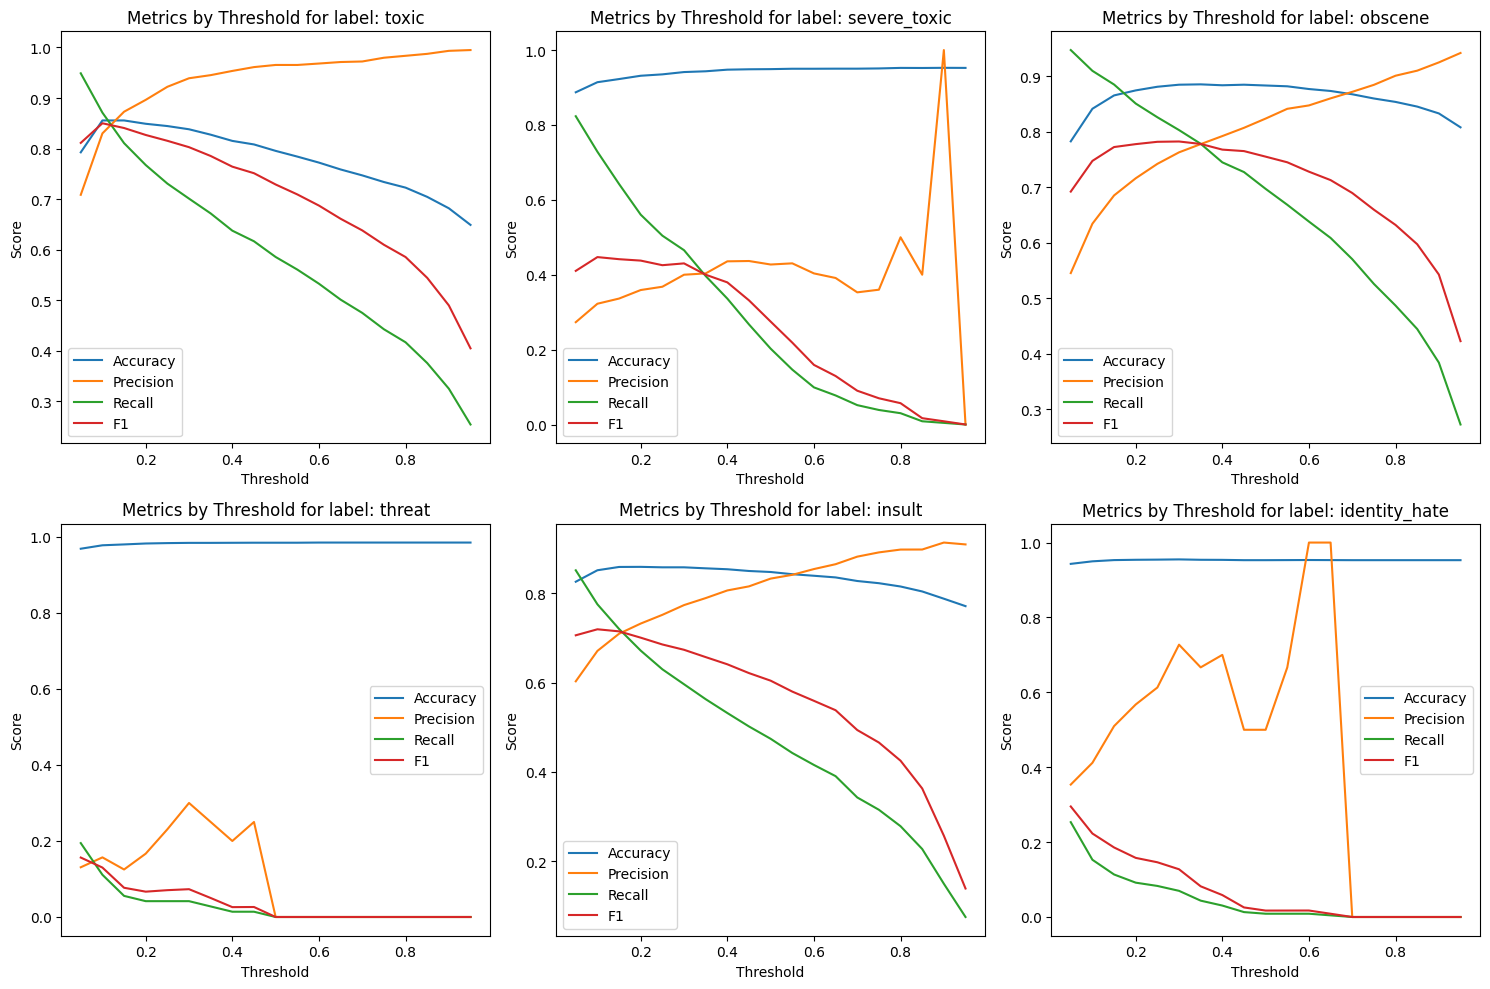

In [50]:
thresh_eval(metrics_dictionary, thresholds_sim)

L'accuracy sostanzialmente non è mai un problema e come ci si aspettava, le valutazioni si spostano su precision e recall. Detto questo però, non si è scelto la soglia migliore massimizzando f1, cioè il bilanciamento tra precision e recall, ma prediligendo sempre la recall a scapito della precision.

Questo perchè si è preferito restituire un modello cautelativo, che piuttosto blocchi commenti in realtà positivi piuttosto che lasciarne passare di negativi.

In [51]:
thresholds_final = [0.1, 0.15, 0.35, 0.05, 0.1, 0.05]

In [52]:
metrics_eval(y_test, y_test_pred, thresholds_final)

LABEL: toxic, TOXICITY WEIGHT: 1.0

[[2173  408]
 [ 295 1992]]
Accuracy for label toxic: 85.56
Precision for label toxic: 83.00
Recall for label toxic: 87.10
F1 for label toxic: 85.00

---

LABEL: severe_toxic, TOXICITY WEIGHT: 3.0

[[4342  294]
 [  83  149]]
Accuracy for label severe_toxic: 92.26
Precision for label severe_toxic: 33.63
Recall for label severe_toxic: 64.22
F1 for label severe_toxic: 44.15

---

LABEL: obscene, TOXICITY WEIGHT: 1.0

[[3334  279]
 [ 278  977]]
Accuracy for label obscene: 88.56
Precision for label obscene: 77.79
Recall for label obscene: 77.85
F1 for label obscene: 77.82

---

LABEL: threat, TOXICITY WEIGHT: 6.0

[[4703   93]
 [  58   14]]
Accuracy for label threat: 96.90
Precision for label threat: 13.08
Recall for label threat: 19.44
F1 for label threat: 15.64

---

LABEL: insult, TOXICITY WEIGHT: 1.0

[[3217  455]
 [ 269  927]]
Accuracy for label insult: 85.13
Precision for label insult: 67.08
Recall for label insult: 77.51
F1 for label insult: 71.92



### Metriche globali

In [62]:
global_metrics_eval(y_test, y_test_pred, thresholds_final)

Global accuracy of the model: 59.59
Global Precision of the model: 72.95
Global Recall of the model: 78.11
Global F1 of the model: 75.17

---



## Conclusioni

Dopo aver tentato la strada del doppio strato bidirezionale LSTM che non ha portato a significative migliorie sulle metriche con un aggravio nei tempi di addestramento importante, si è optato, in ottica rasoio di Ockam, per il singolo strato.

Si ritiene pertanto che, con i dati a disposizione, la configurazione attuale sia stata ottimizzata fino a raggiungere il massimo delle performance possibile. Pesano molto le poche ricorrenze per le classi threat o per identity_hate.

Ciò detto, le performance non sono assolutamente scarse, considerando il modello attuale come una prima iterazione e non la versione definitiva.

Infatti, sulle singole etichette, l'accuracy si attesta tra 85% e 96%. Nonostante la metrica sia ovviamente influenzata dai casi negativi, più presenti, di buon rilievo è il fatto che globalmente la recall e la precisione sono sopra il 70% e l'accuracy al 60%. Questo vuol dire che sull'insieme di test:
- il modello classifica 6 commenti su 10 in maniera identica rispetto ai valori veri su tutte le 6 etichette
- ogni volta che il modello alza una 'bandierina', azzecca quasi 3 volte su quattro
- su tutti i commenti negativi presenti, quasi 8 volte su 10 il modello prende la negatività

### Suggerimenti

Alla luce dei risultati confortanti espressi dal modello, si consiglia, per poterlo portare a livelli di performance più alti, di rilasciarlo in produzione e avviare una fase di affiancamento umano al modello.

In questa fase verranno passati al vaglio i commenti scartati dal modello per essere classificati correttamente. Ogni 2 settimane od ogni mese, verrà effettuato un nuovo addestramento sul modello con poche epoche, stessi pesi dell'addestramento precedente e un nuovo dataset composto dall'insieme di addestramento vecchio con l'aggiunta di tutte le interpretazioni errate del modello.

In particolare, concentrarsi sulla raccolta delle classi meno rappresentate, così da dare al modello la possibilità di apprendere